In [30]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection    import (train_test_split, StratifiedKFold,
                                         cross_val_score)
from sklearn.preprocessing      import RobustScaler
from sklearn.ensemble           import (RandomForestClassifier,
                                         ExtraTreesClassifier,
                                         GradientBoostingClassifier,
                                         BaggingClassifier,
                                         StackingClassifier)
from sklearn.tree               import DecisionTreeClassifier
from sklearn.linear_model       import LogisticRegression
from sklearn.decomposition      import PCA
from sklearn.metrics            import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, precision_score, recall_score, accuracy_score,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
np.random.seed(42)

In [31]:
DATASET_PATH = "/home/fyp_ids_e20/processed_dataset/balanced_application_data.csv"
LABEL_COLUMN = "Label"
BENIGN_LABEL = "Benign"

MODELS_DIR  = "models"
RESULTS_DIR = os.path.join("results", "layer2")
os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

TEST_SIZE   = 0.20
VAL_SIZE    = 0.10
RANDOM_SEED = 42
CV_FOLDS    = 5

UNKNOWN_FRACTION       = 0.10   
UNKNOWN_ATTACK_CLASSES = []     

APPLICATION_FEATURES = [
    "Pkt Size Avg",
    "Pkt Len Mean",
    "Pkt Len Max",
    "Pkt Len Min",
    "Pkt Len Std",
    "Pkt Len Var",
    "Fwd Pkt Len Max",
    "Fwd Pkt Len Min",
    "Fwd Pkt Len Mean",
    "Fwd Pkt Len Std",
    "Bwd Pkt Len Max",
    "Bwd Pkt Len Min",
    "Bwd Pkt Len Mean",
    "Bwd Pkt Len Std",
    "Fwd Seg Size Min",
    "Fwd Seg Size Avg",
    "Bwd Seg Size Avg",
    "TotLen Fwd Pkts",
    "Subflow Fwd Byts"
]

In [32]:
df = pd.read_csv(DATASET_PATH, low_memory=False)
df.columns       = df.columns.str.strip()
df[LABEL_COLUMN] = df[LABEL_COLUMN].astype(str).str.strip()

df_atk = df[df[LABEL_COLUMN] != BENIGN_LABEL].copy().reset_index(drop=True)
print(f"Total rows  : {len(df):,}")
print(f"Attack rows : {len(df_atk):,}  (benign dropped)")

found   = [f for f in APPLICATION_FEATURES if f in df_atk.columns]
missing = [f for f in APPLICATION_FEATURES if f not in df_atk.columns]
print(f"\nFeatures found   : {len(found)} / {len(APPLICATION_FEATURES)}")
if missing: print(f"Features missing : {missing}")

counts = df_atk[LABEL_COLUMN].value_counts()
print("\nAttack class distribution:")
for cls, cnt in counts.items():
    bar = chr(9608) * int(30 * cnt / counts.max())
    print(f"  {cls:<38}  {cnt:>8,}  {bar}")

X      = df_atk[found].values.astype(np.float64)
labels = df_atk[LABEL_COLUMN].reset_index(drop=True)

Total rows  : 6,870,587
Attack rows : 2,748,235  (benign dropped)

Features found   : 19 / 19

Attack class distribution:
  DDOS attack-HOIC                         686,012  ██████████████████████████████
  DDoS attacks-LOIC-HTTP                   576,191  █████████████████████████
  DoS attacks-Hulk                         461,912  ████████████████████
  Bot                                      286,191  ████████████
  FTP-BruteForce                           193,360  ████████
  SSH-Bruteforce                           187,589  ████████
  Infilteration                            161,934  ███████
  DoS attacks-SlowHTTPTest                 139,890  ██████
  DoS attacks-GoldenEye                     41,508  █
  DoS attacks-Slowloris                     10,990  
  DDOS attack-LOIC-UDP                       1,730  
  Brute Force -Web                             611  
  Brute Force -XSS                             230  
  SQL Injection                                 87  


In [33]:
all_classes = set(labels.unique())

if UNKNOWN_ATTACK_CLASSES:
    unknown = set(UNKNOWN_ATTACK_CLASSES) & all_classes
    print(f"Option B: {len(unknown)} explicit unknown class(es)")
else:
    n_unk   = max(1, int(len(all_classes) * UNKNOWN_FRACTION))
    unknown = set(counts.tail(n_unk).index)
    print(f"Option A: bottom {UNKNOWN_FRACTION*100:.0f}% rarest -> {n_unk} unknown")

known = all_classes - unknown
print(f"\nKnown   ({len(known)})  -> Layer 3:")
for c in sorted(known):   print(f"  +  {c}")
print(f"\nUnknown ({len(unknown)})  -> alert admin:")
for c in sorted(unknown): print(f"  -  {c}")

with open(os.path.join(MODELS_DIR,"layer2_known_classes.txt"),"w") as fh:
    for c in sorted(known): fh.write(c+"\n")
print(f"\nSaved -> {MODELS_DIR}/layer2_known_classes.txt")

Option A: bottom 10% rarest -> 1 unknown

Known   (13)  -> Layer 3:
  +  Bot
  +  Brute Force -Web
  +  Brute Force -XSS
  +  DDOS attack-HOIC
  +  DDOS attack-LOIC-UDP
  +  DDoS attacks-LOIC-HTTP
  +  DoS attacks-GoldenEye
  +  DoS attacks-Hulk
  +  DoS attacks-SlowHTTPTest
  +  DoS attacks-Slowloris
  +  FTP-BruteForce
  +  Infilteration
  +  SSH-Bruteforce

Unknown (1)  -> alert admin:
  -  SQL Injection

Saved -> models/layer2_known_classes.txt


In [34]:
y = labels.isin(known).astype(int).values

X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y)
val_frac = VAL_SIZE / (1.0 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=val_frac, random_state=RANDOM_SEED, stratify=y_tv)

print(f"{'Split':<12} {'Total':>8}  {'Known':>8}  {'Unknown':>8}  {'Known%':>8}")
print("-"*55)
for name, X_, y_ in [("Train",X_train,y_train),("Validation",X_val,y_val),("Test",X_test,y_test)]:
    nk=(y_==1).sum(); nu=(y_==0).sum()
    print(f"{name:<12} {len(y_):>8,}  {nk:>8,}  {nu:>8,}  {100*nk/len(y_):>7.1f}%")

Split           Total     Known   Unknown    Known%
-------------------------------------------------------
Train        1,923,764  1,923,703        61    100.0%
Validation    274,824   274,815         9    100.0%
Test          549,647   549,630        17    100.0%


In [35]:
scaler_path = os.path.join(MODELS_DIR, "/home/fyp_ids_e20/Eniyavan/Layer_models/layer1/models/layer1_scaler.pkl")
if os.path.exists(scaler_path):
    scaler = joblib.load(scaler_path)
    print(f"Loaded Layer 1 scaler <- {scaler_path}")
else:
    scaler = RobustScaler()
    scaler.fit(X_train)
    joblib.dump(scaler, os.path.join(MODELS_DIR,"layer2_scaler.pkl"))
    print("New RobustScaler fitted and saved.")

X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)
print(f"Scaled: Train{X_train_s.shape}  Val{X_val_s.shape}  Test{X_test_s.shape}")

Loaded Layer 1 scaler <- /home/fyp_ids_e20/Eniyavan/Layer_models/layer1/models/layer1_scaler.pkl
Scaled: Train(1923764, 19)  Val(274824, 19)  Test(549647, 19)


In [36]:
n_known_before   = (y_train == 1).sum()
n_unknown_before = (y_train == 0).sum()
print(f"Before — Known: {n_known_before:,}  Unknown: {n_unknown_before:,}  "
      f"ratio: {n_known_before/max(n_unknown_before,1):.1f}:1")

if n_unknown_before < n_known_before:
    rng     = np.random.RandomState(RANDOM_SEED)
    idx_min = np.where(y_train == 0)[0]
    n_extra = n_known_before - n_unknown_before
    extra   = rng.choice(idx_min, size=n_extra, replace=True)
    X_train_s = np.vstack([X_train_s, X_train_s[extra]])
    y_train   = np.concatenate([y_train, y_train[extra]])
    perm      = rng.permutation(len(y_train))
    X_train_s = X_train_s[perm]
    y_train   = y_train[perm]

n_known_after   = (y_train == 1).sum()
n_unknown_after = (y_train == 0).sum()
print(f"After  — Known: {n_known_after:,}  Unknown: {n_unknown_after:,}  "
      f"ratio: {n_known_after/max(n_unknown_after,1):.1f}:1")

Before — Known: 1,923,703  Unknown: 61  ratio: 31536.1:1
After  — Known: 1,923,703  Unknown: 1,923,703  ratio: 1.0:1


In [37]:
n_neg    = int((y_train == 0).sum())
n_pos    = int((y_train == 1).sum())
scale_pw = n_neg / n_pos if n_pos > 0 else 1.0

base_defs = [
    ("Random Forest", RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_split=5,
        min_samples_leaf=2, class_weight="balanced",
        random_state=RANDOM_SEED, n_jobs=-1)),

    ("XGBoost", XGBClassifier(
        n_estimators=300, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pw, use_label_encoder=False,
        eval_metric="logloss", random_state=RANDOM_SEED, n_jobs=-1)),

    ("Extra Trees", ExtraTreesClassifier(
        n_estimators=300, max_depth=None, min_samples_split=5,
        min_samples_leaf=2, class_weight="balanced",
        random_state=RANDOM_SEED, n_jobs=-1)),

    ("Gradient Boost", GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=RANDOM_SEED)),

    ("Bagging DT", BaggingClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=10, class_weight="balanced", random_state=RANDOM_SEED),
        n_estimators=200, max_samples=0.8, max_features=0.8,
        bootstrap=True, random_state=RANDOM_SEED, n_jobs=-1)),
]

trained = {}
for name, clf in base_defs:
    t0 = time.time()
    clf.fit(X_train_s, y_train)
    val_acc = accuracy_score(y_val, clf.predict(X_val_s))
    val_f1  = f1_score(y_val, clf.predict(X_val_s), zero_division=0)
    print(f"  {name:<20}  {time.time()-t0:5.1f}s  "
          f"val_acc={val_acc*100:.2f}%  val_f1={val_f1:.4f}")
    joblib.dump(clf, os.path.join(MODELS_DIR,
                f"layer2_{name.lower().replace(' ','_')}.pkl"))
    trained[name] = clf
print("\nAll 5 base models saved.")

  Random Forest          28.0s  val_acc=64.53%  val_f1=0.7844
  XGBoost                 7.0s  val_acc=64.53%  val_f1=0.7844
  Extra Trees            31.9s  val_acc=64.53%  val_f1=0.7844
  Gradient Boost        958.6s  val_acc=64.53%  val_f1=0.7844
  Bagging DT             53.8s  val_acc=64.52%  val_f1=0.7844

All 5 base models saved.


In [38]:
estimators = [(nm.lower().replace(" ","_"), m) for nm,m in trained.items()]
stacker = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(
        max_iter=1000, C=1.0, class_weight="balanced",
        random_state=RANDOM_SEED),
    cv=5,
    stack_method="predict_proba",
    n_jobs=-1,
    passthrough=False,
)
t0 = time.time()
stacker.fit(X_train_s, y_train)
val_acc = accuracy_score(y_val, stacker.predict(X_val_s))
val_f1  = f1_score(y_val, stacker.predict(X_val_s), zero_division=0)
print(f"Stacking — {time.time()-t0:.1f}s  "
      f"val_acc={val_acc*100:.2f}%  val_f1={val_f1:.4f}")

trained["Stacking"] = stacker
joblib.dump(stacker, os.path.join(MODELS_DIR, "layer2_stacking.pkl"))
print(f"Saved -> {MODELS_DIR}/layer2_stacking.pkl")

[16:45:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[16:45:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[16:45:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[16:45:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[16:45:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



Stacking — 2219.9s  val_acc=64.53%  val_f1=0.7844
Saved -> models/layer2_stacking.pkl


In [39]:
thresholds = {}
print(f"{'Model':<22}  {'Best Thr':>9}  {'Val F1':>7}")
print("-"*45)
for name, clf in trained.items():
    proba = clf.predict_proba(X_val_s)[:, 1]
    prec, rec, thr = precision_recall_curve(y_val, proba)
    f1s   = 2*prec*rec/(prec+rec+1e-9)
    best  = int(np.argmax(f1s[:-1]))
    best_t = float(thr[best])
    print(f"  {name:<22}  {best_t:>9.4f}  {f1s[best]:>7.4f}")
    thresholds[name] = best_t

with open(os.path.join(MODELS_DIR,"layer2_thresholds.json"),"w") as fh:
    json.dump(thresholds, fh, indent=2)
print(f"\nSaved -> {MODELS_DIR}/layer2_thresholds.json")

Model                    Best Thr   Val F1
---------------------------------------------
  Random Forest              0.4270   1.0000
  XGBoost                    0.4270   1.0000
  Extra Trees                0.4380   1.0000
  Gradient Boost             0.0552   1.0000
  Bagging DT                 0.1161   1.0000
  Stacking                   0.4274   1.0000

Saved -> models/layer2_thresholds.json


In [40]:
results     = []
model_names = list(trained.keys())
palette     = ["steelblue","darkorange","seagreen","mediumpurple","tomato","goldenrod"]
all_preds   = []
all_prob    = []

for name, clf in trained.items():
    proba = clf.predict_proba(X_test_s)[:, 1]
    thr   = thresholds.get(name, 0.5)
    preds = (proba >= thr).astype(int)
    all_prob.append(proba)
    all_preds.append(preds)

    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec  = recall_score(y_test,    preds, zero_division=0)
    f1   = f1_score(y_test,        preds, zero_division=0)
    try:    auc = roc_auc_score(y_test, proba)
    except: auc = None

    status = "TARGET MET" if acc >= 0.90 else "Below 90%"
    print(f"{'='*50}\n  {name}")
    print(f"  Accuracy  : {acc*100:.4f}%   [{status}]")
    print(f"  Precision : {prec:.4f}  Recall : {rec:.4f}  F1 : {f1:.4f}")
    if auc: print(f"  ROC-AUC   : {auc:.4f}")
    print(classification_report(y_test,preds,target_names=["Unknown","Known"],digits=4))
    results.append({"Model":name,"Accuracy%":round(acc*100,4),
                    "Precision":round(prec,4),"Recall":round(rec,4),
                    "F1":round(f1,4),"ROC-AUC":round(auc,4) if auc else "N/A",
                    "90%+ Met":"Yes" if acc>=0.90 else "No"})

df_results = pd.DataFrame(results).sort_values("Accuracy%", ascending=False)
df_results.to_csv(os.path.join(RESULTS_DIR,"layer2_model_summary.csv"), index=False)
print("\n" + "-"*62)
print(df_results.to_string(index=False))

  Random Forest
  Accuracy  : 99.9985%   [TARGET MET]
  Precision : 1.0000  Recall : 1.0000  F1 : 1.0000
  ROC-AUC   : 0.9062
              precision    recall  f1-score   support

     Unknown     1.0000    0.5294    0.6923        17
       Known     1.0000    1.0000    1.0000    549630

    accuracy                         1.0000    549647
   macro avg     1.0000    0.7647    0.8462    549647
weighted avg     1.0000    1.0000    1.0000    549647

  XGBoost
  Accuracy  : 99.9985%   [TARGET MET]
  Precision : 1.0000  Recall : 1.0000  F1 : 1.0000
  ROC-AUC   : 0.9062
              precision    recall  f1-score   support

     Unknown     1.0000    0.5294    0.6923        17
       Known     1.0000    1.0000    1.0000    549630

    accuracy                         1.0000    549647
   macro avg     1.0000    0.7647    0.8462    549647
weighted avg     1.0000    1.0000    1.0000    549647

  Extra Trees
  Accuracy  : 99.9985%   [TARGET MET]
  Precision : 1.0000  Recall : 1.0000  F1 : 1.00

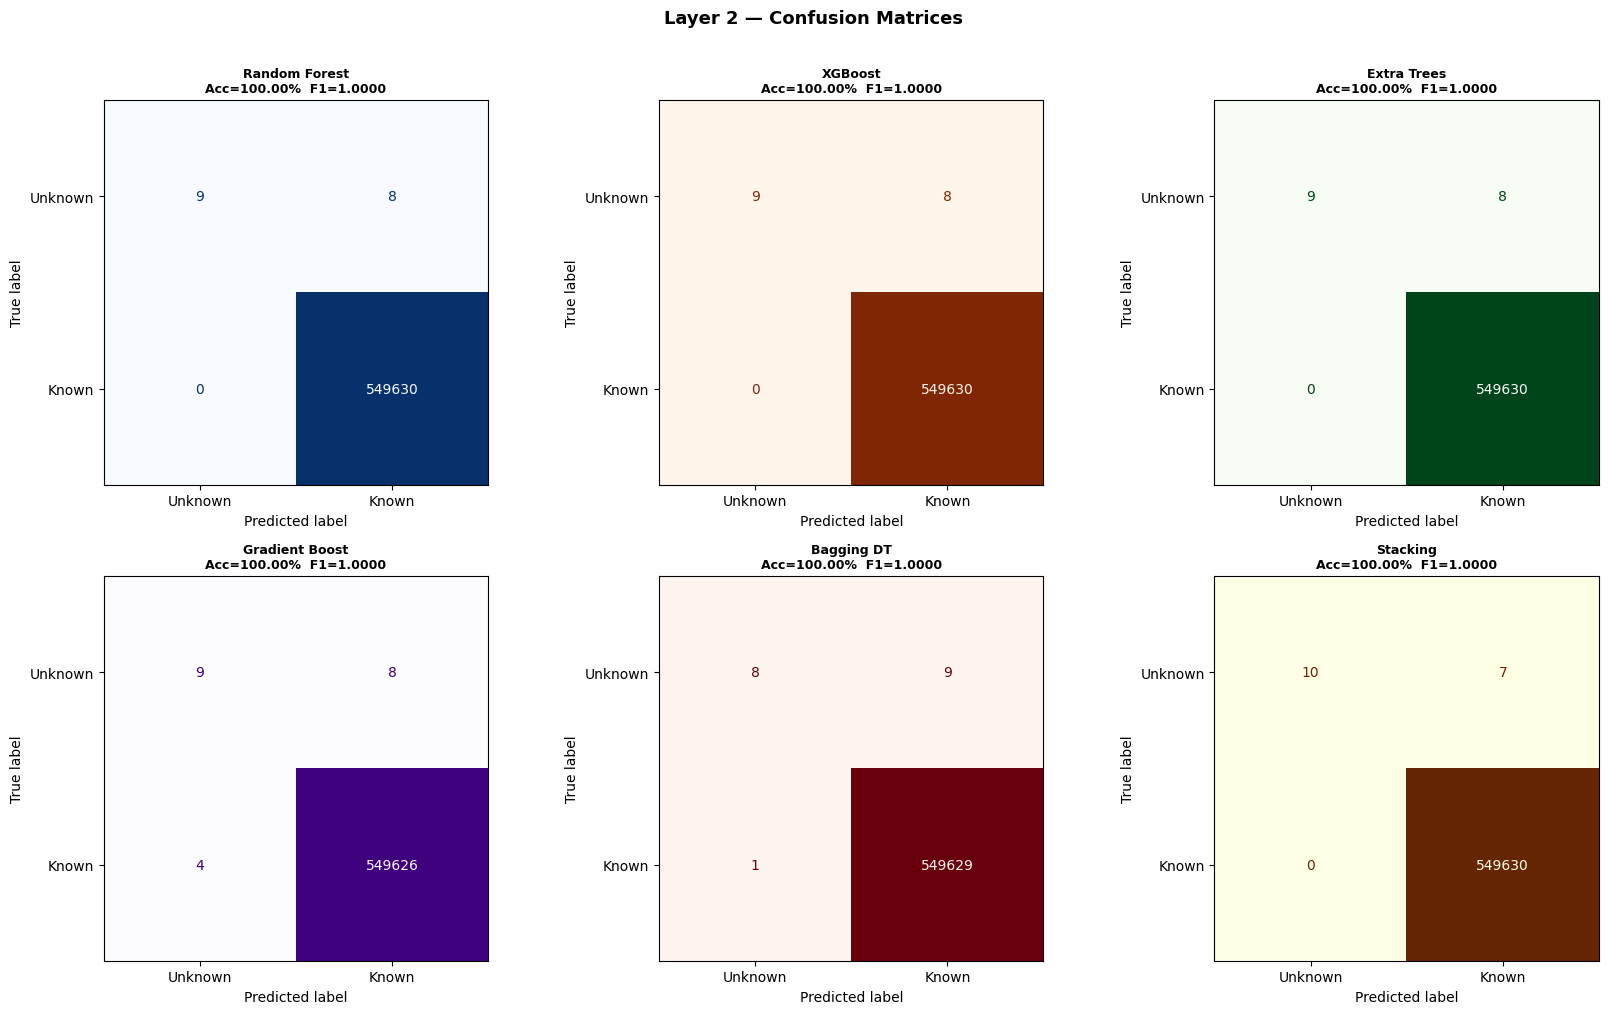

In [41]:
n_models = len(model_names)
ncols = 3; nrows = (n_models+2)//3
cmaps = ["Blues","Oranges","Greens","Purples","Reds","YlOrBr"]
fig, axes = plt.subplots(nrows, ncols, figsize=(17,5*nrows))
axes = axes.flatten()
for i,(nm,preds) in enumerate(zip(model_names,all_preds)):
    acc = accuracy_score(y_test,preds); f1=f1_score(y_test,preds,zero_division=0)
    ConfusionMatrixDisplay(confusion_matrix(y_test,preds),
                           display_labels=["Unknown","Known"]).plot(
        ax=axes[i],colorbar=False,cmap=cmaps[i])
    axes[i].set_title(f"{nm}\nAcc={acc*100:.2f}%  F1={f1:.4f}",fontsize=9,fontweight="bold")
for j in range(i+1,len(axes)): axes[j].axis("off")
plt.suptitle("Layer 2 — Confusion Matrices",fontsize=13,fontweight="bold",y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"layer2_confusion_matrices.png"),dpi=150,bbox_inches="tight")
plt.show()

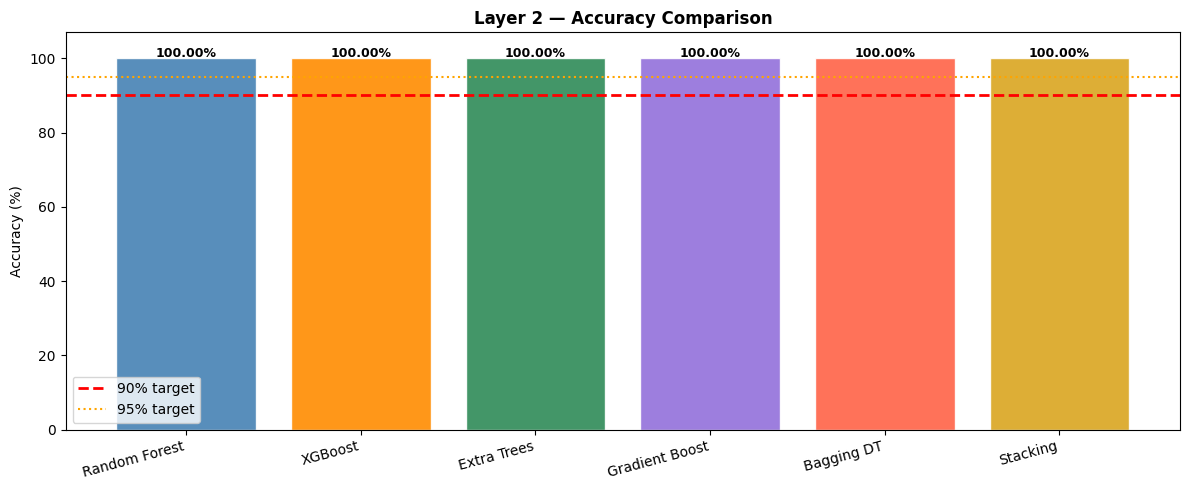

In [42]:
accs = [accuracy_score(y_test,p)*100 for p in all_preds]
fig, ax = plt.subplots(figsize=(12,5))
bars = ax.bar(model_names,accs,color=palette[:n_models],edgecolor="white",alpha=0.9)
ax.axhline(90,color="red",linestyle="--",lw=2,label="90% target")
ax.axhline(95,color="orange",linestyle=":",lw=1.5,label="95% target")
for bar,v in zip(bars,accs):
    ax.text(bar.get_x()+bar.get_width()/2,v+0.3,f"{v:.2f}%",
            ha="center",fontsize=9,fontweight="bold")
ax.set_ylim(0,107); ax.set_ylabel("Accuracy (%)")
ax.set_title("Layer 2 — Accuracy Comparison",fontweight="bold")
ax.legend(); plt.xticks(rotation=15,ha="right"); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"layer2_accuracy_comparison.png"),dpi=150,bbox_inches="tight")
plt.show()

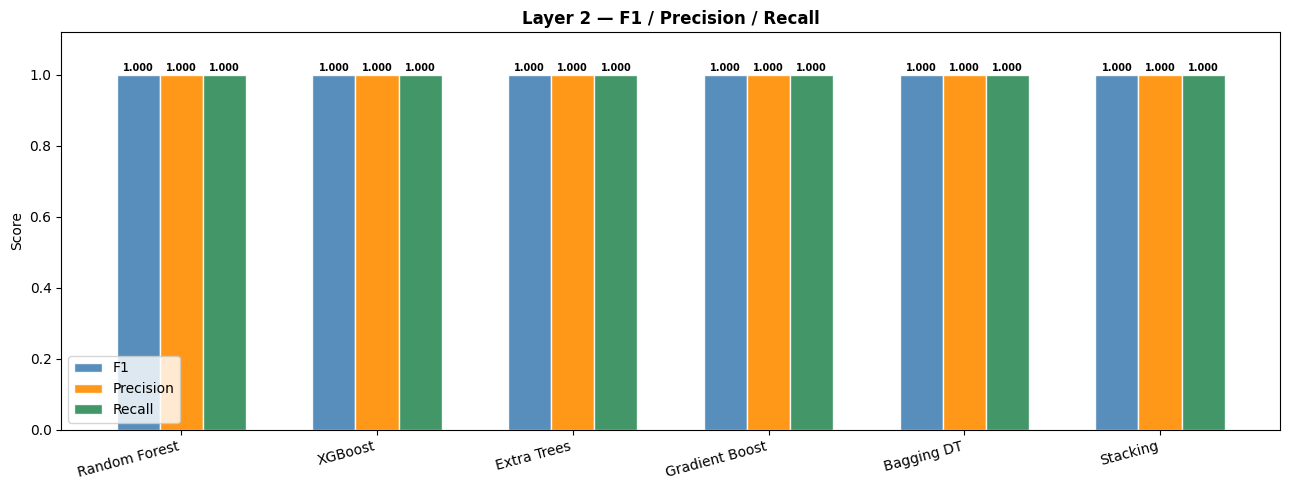

In [43]:
f1s=[f1_score(y_test,p,zero_division=0) for p in all_preds]
precs=[precision_score(y_test,p,zero_division=0) for p in all_preds]
recs=[recall_score(y_test,p,zero_division=0) for p in all_preds]
x,w=np.arange(n_models),0.22
fig,ax=plt.subplots(figsize=(13,5))
for i_,(met,vals,col) in enumerate([("F1",f1s,"steelblue"),("Precision",precs,"darkorange"),("Recall",recs,"seagreen")]):
    bs=ax.bar(x+i_*w,vals,w,label=met,color=col,edgecolor="white",alpha=0.9)
    for b,v in zip(bs,vals):
        ax.text(b.get_x()+b.get_width()/2,v+0.005,f"{v:.3f}",ha="center",va="bottom",fontsize=7,fontweight="bold")
ax.set_xticks(x+w); ax.set_xticklabels(model_names,rotation=15,ha="right")
ax.set_ylim(0,1.12); ax.set_ylabel("Score"); ax.legend()
ax.set_title("Layer 2 — F1 / Precision / Recall",fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"layer2_f1_comparison.png"),dpi=150,bbox_inches="tight")
plt.show()

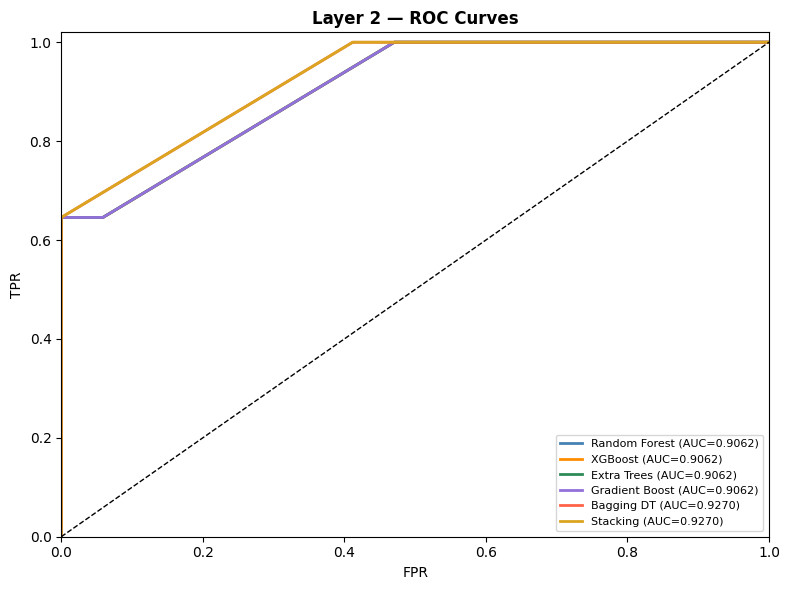

In [44]:
fig,ax=plt.subplots(figsize=(8,6))
for nm,prob,col in zip(model_names,all_prob,palette):
    try:
        fpr,tpr,_=roc_curve(y_test,prob); auc=roc_auc_score(y_test,prob)
        ax.plot(fpr,tpr,color=col,lw=2,label=f"{nm} (AUC={auc:.4f})")
    except: pass
ax.plot([0,1],[0,1],"k--",lw=1)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("Layer 2 — ROC Curves",fontweight="bold"); ax.legend(fontsize=8)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02]); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"layer2_roc_curves.png"),dpi=150,bbox_inches="tight")
plt.show()

In [ ]:
fig,ax=plt.subplots(figsize=(8,6))
for nm,prob,col in zip(model_names,all_prob,palette):
    try:
        pr,rc,_=precision_recall_curve(y_test,prob)
        ap=float(np.trapz(pr[::-1],rc[::-1]))
        ax.plot(rc,pr,color=col,lw=2,label=f"{nm} (AP={ap:.4f})")
    except: pass
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Layer 2 — PR Curves",fontweight="bold"); ax.legend(fontsize=8)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02]); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"layer2_pr_curves.png"),dpi=150,bbox_inches="tight")
plt.show()

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(16,8))
for ax,(nm,col) in zip(axes,[("Random Forest","steelblue"),("Extra Trees","seagreen")]):
    if nm in trained:
        imp=trained[nm].feature_importances_; idx=np.argsort(imp)
        bs=ax.barh([found[i] for i in idx],imp[idx],color=col,edgecolor="white")
        for b,v in zip(bs,imp[idx]):
            ax.text(v+0.001,b.get_y()+b.get_height()/2,f"{v:.3f}",va="center",fontsize=8)
        ax.set_xlabel("Importance"); ax.set_title(f"{nm}",fontweight="bold")
plt.suptitle("Layer 2 — Feature Importance Comparison",fontsize=13,fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"layer2_feature_importance.png"),dpi=150,bbox_inches="tight")
plt.show()

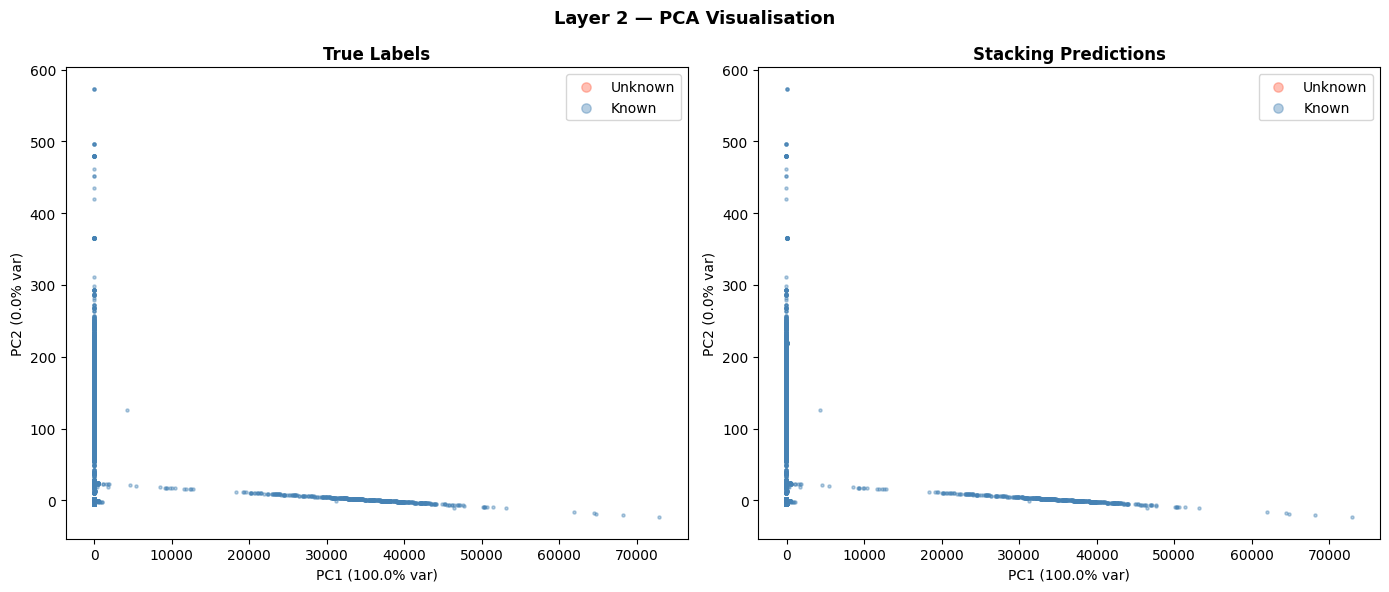

In [46]:
pca=PCA(n_components=2,random_state=RANDOM_SEED); X2d=pca.fit_transform(X_test_s)
var=pca.explained_variance_ratio_; stk_pred=all_preds[-1]
cmap_={0:("Unknown","tomato"),1:("Known","steelblue")}
fig,axes=plt.subplots(1,2,figsize=(14,6))
for ax,(lbl,title) in zip(axes,[(y_test,"True Labels"),(stk_pred,"Stacking Predictions")]):
    for cls,(cname,col) in cmap_.items():
        mask=(lbl==cls); ax.scatter(X2d[mask,0],X2d[mask,1],c=col,s=5,alpha=0.4,label=cname)
    ax.set_xlabel(f"PC1 ({100*var[0]:.1f}% var)"); ax.set_ylabel(f"PC2 ({100*var[1]:.1f}% var)")
    ax.set_title(title,fontweight="bold"); ax.legend(markerscale=3)
plt.suptitle("Layer 2 — PCA Visualisation",fontsize=13,fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"layer2_pca_visualisation.png"),dpi=150,bbox_inches="tight")
plt.show()

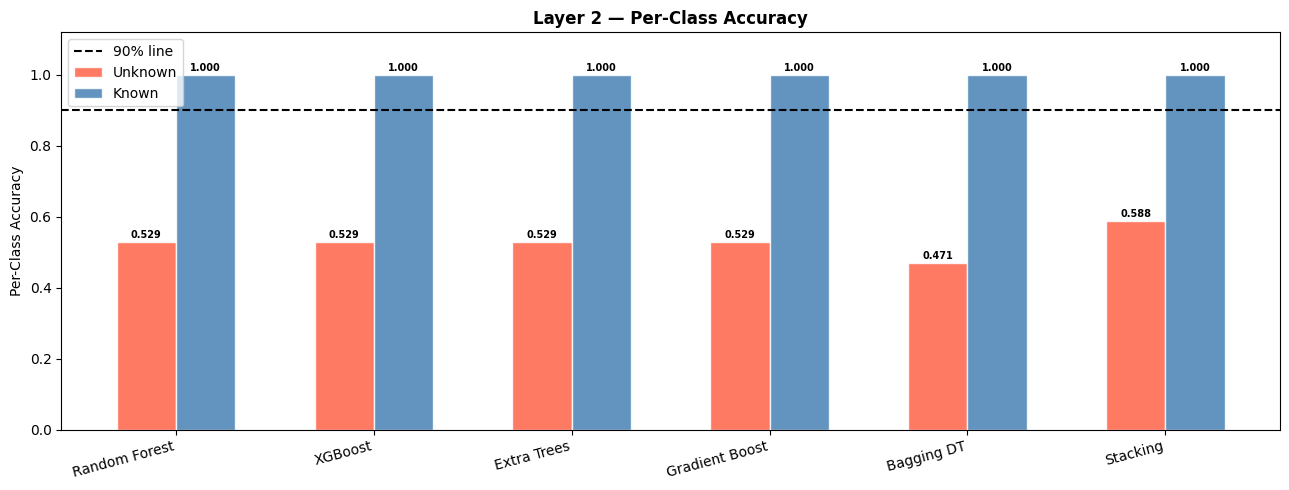

In [47]:
fig,ax=plt.subplots(figsize=(13,5)); x9,w9=np.arange(n_models),0.3
for i_,cls in enumerate([0,1]):
    cls_acc=[float((p[y_test==cls]==cls).mean()) if (y_test==cls).sum()>0 else 0 for p in all_preds]
    col_="tomato" if cls==0 else "steelblue"; lbl_="Unknown" if cls==0 else "Known"
    bs=ax.bar(x9+i_*w9,cls_acc,w9,label=lbl_,color=col_,edgecolor="white",alpha=0.85)
    for b,v in zip(bs,cls_acc):
        ax.text(b.get_x()+b.get_width()/2,v+0.005,f"{v:.3f}",ha="center",va="bottom",fontsize=7,fontweight="bold")
ax.axhline(0.90,color="black",linestyle="--",lw=1.5,label="90% line")
ax.set_xticks(x9+w9/2); ax.set_xticklabels(model_names,rotation=15,ha="right")
ax.set_ylim(0,1.12); ax.set_ylabel("Per-Class Accuracy")
ax.set_title("Layer 2 — Per-Class Accuracy",fontweight="bold"); ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"layer2_per_class_accuracy.png"),dpi=150,bbox_inches="tight")
plt.show()

In [48]:
best_idx=df_results["Accuracy%"].idxmax()
best_name=df_results.loc[best_idx,"Model"]
best_acc=float(df_results.loc[best_idx,"Accuracy%"])

cfg={"best_model":best_name,"best_accuracy_%":best_acc,
     "best_f1":float(df_results.loc[best_idx,"F1"]),
     "unknown_fraction":UNKNOWN_FRACTION,
     "unknown_classes":sorted(unknown),"known_classes":sorted(known),
     "label_column":LABEL_COLUMN,"features":found}
with open(os.path.join(MODELS_DIR,"layer2_config.json"),"w") as fh:
    json.dump(cfg,fh,indent=2)

status="TARGET MET" if best_acc>=90 else "NOT YET MET"
print(f"90% Target  : {status}")
print(f"Best model  : {best_name}  ({best_acc:.4f}%)")
print("\nNext -> run  notebook_03_layer3_supervised_classifier.ipynb")

90% Target  : TARGET MET
Best model  : Stacking  (99.9987%)

Next -> run  notebook_03_layer3_supervised_classifier.ipynb
